---
numbering:
  enumerator: "21.%s"
  equation:
    template: "%s"  
---
(chap_unsup)=
# Unsupervised learning

All algorithms presented in Chapters {ref}`chap_lasso` to {ref}`chap_bayes` belong to the larger class of supervised learning tools. Such tools seek to unveil a mapping between predictors $\textbf{X}$ and a label $\textbf{Z}$. The supervision comes from the fact that it is asked that the data tries to explain this particular variable $\textbf{Z}$. Another important part of machine learning consists of unsupervised tasks, that is, when $\textbf{Z}$ is not specified and the algorithm tries to make sense of $\textbf{X}$ on its own. Often, relationships between the components of $\textbf{X}$ are identified. This field is much too vast to be summarized in one book, let alone one chapter. The purpose here is to briefly explain in what ways unsupervised learning can be used, especially in the data pre-processing phase.

(corpred)=
## The problem with correlated predictors

Often, it is tempting to supply all predictors to a ML-fueled predictive engine. That may not be a good idea when some predictors are highly correlated. To illustrate this, the simplest example is a regression on two variables with zero mean and covariance and precisions matrices:

$$\boldsymbol{\Sigma}=\textbf{X}'\textbf{X}=\begin{bmatrix} 1 & \rho \\ \rho & 1 \end{bmatrix},  \quad \boldsymbol{\Sigma}^{-1}=\frac{1}{1-\rho^2}\begin{bmatrix} 1 & -\rho \\ -\rho & 1 \end{bmatrix}.$$

When the covariance/correlation $\rho$ increase towards 1 (the two variables are co-linear), the scaling denominator in $\boldsymbol{\Sigma}^{-1}$ goes to zero and the formula $\hat{\boldsymbol{\beta}}=\boldsymbol{\Sigma}^{-1}\textbf{X}'\textbf{Z}$ implies that one coefficient will be highly positive and one highly negative. The regression creates a spurious arbitrage between the two variables. Of course, this is very inefficient and yields disastrous results out-of-sample. 

We illustrate what happens when many variables are used in the regression below. One elucidation of the aforementioned phenomenon comes from the variables Mkt_Cap_12M and Mkt_Cap_6M, which have a correlation of 99.6% in the training sample. Both are singled out as highly significant but their signs are contradictory. Moreover, the magnitude of their coefficients are very close (0.21 versus 0.18) so that their net effect cancels out. Naturally, providing the regression with only one of these two inputs would have been wiser.

In [ ]:
%config InlineBackend.figure_formats = ['png', 'pdf']


In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

# Load data
from data_build import generate_data                                                              
data_ml, features, features_short, returns, stock_ids, stock_ids_short = generate_data()          
                                                                                                    
# Create training and testing samples                                                             
separation_date = "2017-01-15"                                                                    
training_sample = data_ml[data_ml['date'] < separation_date]                                      
testing_sample = data_ml[data_ml['date'] >= separation_date] 

In [2]:
# Regression with all features to show multicollinearity problem
X = training_sample[features].copy()
y = training_sample['R1M'].copy()

# Add constant for intercept
X_const = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X_const).fit()

# Get summary and filter significant predictors (|t| > 3)
results_df = pd.DataFrame({
    'term': model.params.index,
    'estimate': model.params.values,
    'std_error': model.bse.values,
    'statistic': model.tvalues.values,
    'p_value': model.pvalues.values
})

# Filter for significant predictors
significant = results_df[np.abs(results_df['statistic']) > 3].round(4)
print("Significant predictors in the training sample:")
significant

Significant predictors in the training sample:


,term,estimate,std_error,statistic,p_value
0,const,-0.0,0.0,-1.193590e+01,0.0
1,Asset_Turn,-0.0,0.0,-9.180100e+00,0.0
2,Basic_EPS_Growth_1Y,0.0,0.0,5.429300e+00,0.0
3,Book_Value_PS,0.0,0.0,1.067430e+01,0.0
4,Buyback_Yield,-0.0,0.0,-2.701570e+01,0.0
...,...,...,...,...,...
117,vol_22,-0.0,0.0,-2.227660e+01,0.0
119,vol_66,0.0,0.0,3.667380e+01,0.0
120,Mom_Sharp_11M,-0.0,0.0,-3.012990e+01,0.0
121,Mom_Sharp_5M,-0.0,0.0,-2.813200e+01,0.0


In fact, there are several indicators for the market capitalization and maybe only one would suffice, but it is not obvious to tell which one is the best choice. 

To further depict correlation issues, we compute the correlation matrix of the predictors below (on the training sample). Because of its dimension, we show it graphically.

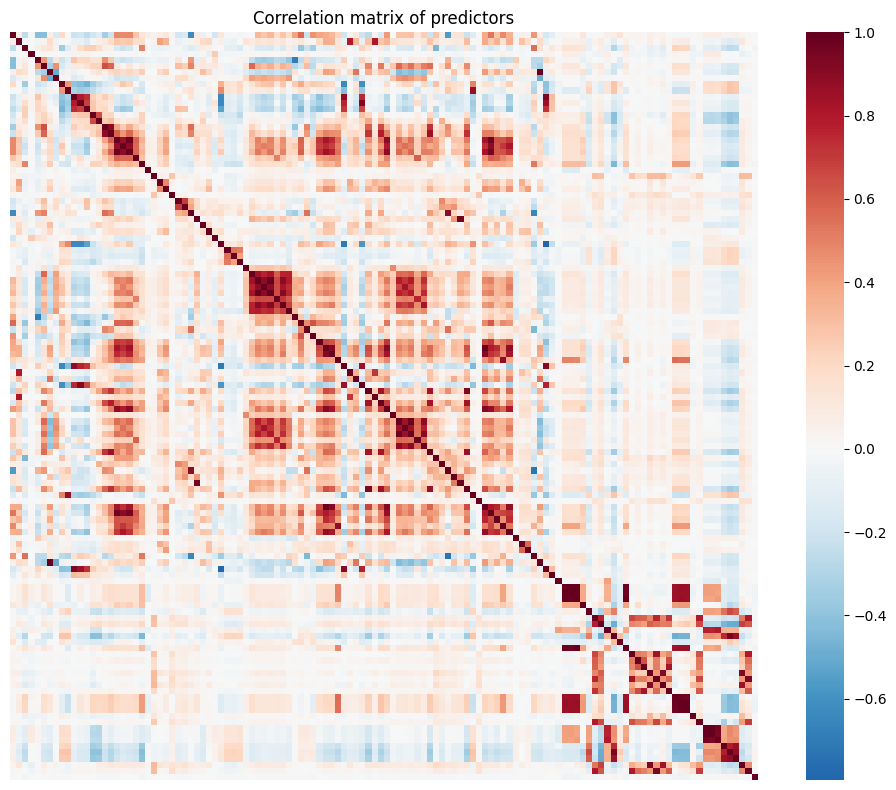

In [3]:
# Correlation matrix visualization
C = training_sample[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(C, cmap='RdBu_r', center=0, 
            xticklabels=False, yticklabels=False,
            square=True)
plt.title('Correlation matrix of predictors')
plt.tight_layout()
plt.show()

The graph reveals several blue squares around the diagonal. For instance, the biggest square around the first third of features relates to all accounting ratios based on free cash flows. Because of this common term in their calculation, the features are naturally highly correlated. These local correlation patterns occur several times in the dataset and explain why it is not a good idea to use simple regression with this set of features.   

In full disclosure, **multicollinearity** (when predictors are correlated) can be much less a problem for ML tools than it is for pure statistical inference. In statistics, one central goal is to study the properties of $\beta$ coefficients. Collinearity perturbs this kind of analysis. In machine learning, the aim is to maximize out-of-sample accuracy. If having many predictors can be helpful, then so be it. One simple example can help clarify this matter. When building a regression tree, having many predictors will give more options for the splits. If the features make sense, then they can be useful. The same reasoning applies to random forests and boosted trees. What does matter is that the large spectrum of features helps improve the generalization ability of the model. Their collinearity is irrelevant.

In the remainder of the chapter, we present two approaches that help reduce the number of predictors:    

- the first one aims at creating new variables that are uncorrelated with each other. Low correlation is favorable from an algorithmic point of view, but the new variables lack interpretability;   
- the second one gathers predictors into homogeneous clusters and only one feature should be chosen out of this cluster. Here the rationale is reversed: interpretability is favored over statistical properties because the resulting set of features may still include high correlations, albeit to a lesser point compared to the original one.

## Principal component analysis and autoencoders

The first method is a cornerstone in dimensionality reduction. It seeks to determine a smaller number of factors ($K'<K$) such that:   
- i) the level of explanatory power remains as high as possible;    
- ii) the resulting factors are linear combinations of the original variables;   
- iii) the resulting factors are orthogonal.

### A bit of algebra

In this short subsection, we define some key concepts that are required to fully understand the derivation of principal component analysis (PCA). Henceforth, we work with matrices (in bold fonts). An $I \times K$ matrix $\textbf{X}$ is orthonormal if $I> K$ and $\textbf{X}'\textbf{X}=\textbf{I}_K$. When $I=K$, the (square) matrix is called orthogonal and $\textbf{X}'\textbf{X}=\textbf{X}\textbf{X}'=\textbf{I}_K$, i.e., $\textbf{X}^{-1}=\textbf{X}'$.

One foundational result in matrix theory is the Singular Value Decomposition (SVD, see, e.g., chapter 5 in @meyer2000matrix). The SVD is formulated as follows: any $I \times K$ matrix $\textbf{X}$ can be decomposed into

```{math}
:label: eq:svd
\textbf{X}=\textbf{U} \boldsymbol{\Delta} \textbf{V}',
```

where $\textbf{U}$ ($I\times I$) and $\textbf{V}$ ($K \times K$) are orthogonal and $\boldsymbol{\Delta}$ (with dimensions $I\times K$) is diagonal, i.e., $\Delta_{i,k}=0$ whenever $i\neq k$. In addition, $\Delta_{i,i}\ge 0$: the diagonal terms of $\boldsymbol{\Delta}$ are nonnegative.

For simplicity, we assume below that $\textbf{1}_I'\textbf{X}=\textbf{0}_K'$, i.e., that all columns have zero sum (and hence zero mean). This allows to write that the covariance matrix is equal to its sample estimate $\boldsymbol{\Sigma}_X= \frac{1}{I-1}\textbf{X}'\textbf{X}$.

One crucial feature of covariance matrices is their symmetry. Indeed, real-valued symmetric (square) matrices enjoy a SVD which is much more powerful: when $\textbf{X}$ is symmetric, there exist an orthogonal matrix $\textbf{Q}$ and a diagonal matrix $\textbf{D}$ such that

```{math}
:label: eq:diagonaliz
\textbf{X}=\textbf{Q}\textbf{DQ}'.
```

This process is called **diagonalization** (see chapter 7 in @meyer2000matrix) and conveniently applies to covariance matrices.

### PCA

The goal of PCA is to build a dataset $\tilde{\textbf{X}}$ that has fewer columns but that keeps as much information as possible when compressing the original one, $\textbf{X}$. The key notion is the **change of base**, which is a linear transformation of $\textbf{X}$ into $\textbf{Z}$, a matrix with identical dimension, via 

```{math}
:label: eq:pca
\textbf{Z}=\textbf{XP},
```

where $\textbf{P}$ is a $K \times K$ matrix. There are of course an infinite number of ways to transform $\textbf{X}$ into $\textbf{Z}$, but two fundamental constraints help reduce the possibilities. The first constraint is that the columns of $\textbf{Z}$ be uncorrelated. Having uncorrelated features is desirable because they then all tell different stories and have zero redundancy. The second constraint is that the variance of the columns of $\textbf{Z}$ is highly concentrated. This means that a few factors (columns) will capture most of the explanatory power (signal), while most (the others) will consist predominantly of noise. All of this is coded in the covariance matrix of $\textbf{Z}$:   

- the first condition imposes that the covariance matrix be diagonal;    
- the second condition imposes that the diagonal elements, when ranked in decreasing magnitude, see their value decline (sharply if possible).    

The covariance matrix of $\textbf{Z}$ is 

```{math}
:label: eq:covy
\boldsymbol{\Sigma}_Z=\frac{1}{I-1}\textbf{Z}'\textbf{Z}=\frac{1}{I-1}\textbf{P}'\textbf{X}'\textbf{XP}=\frac{1}{I-1}\textbf{P}'\boldsymbol{\Sigma}_X\textbf{P}.
```

In this expression, we plug the decomposition {eq}`eq:diagonaliz` of $\boldsymbol{\Sigma}_X$:
$$\boldsymbol{\Sigma}_Z=\frac{1}{I-1}\textbf{P}'\textbf{Q}\textbf{DQ}'\textbf{P},$$
thus picking $\textbf{P}=\textbf{Q}$, we get, by orthogonality, $\boldsymbol{\Sigma}_Z=\frac{1}{I-1}\textbf{D}$, that is, a diagonal covariance matrix for $\textbf{Z}$. The columns of $\textbf{Z}$ can then be re-shuffled in decreasing order of variance so that the diagonal elements of $\boldsymbol{\Sigma}_Z$ progressively shrink. This is useful because it helps locate the factors with most informational content (the first factors). In the limit, a constant vector (with zero variance) carries no signal.

The matrix $\textbf{Z}$ is a linear transformation of $\textbf{X}$, thus, it is expected to carry the same information, even though this information is coded differently. Since the columns are ordered according to their relative importance, it is simple to omit some of them. The new set of features $\tilde{\textbf{X}}$ consists in the first $K'$ (with $K'<K$) columns of $\textbf{Z}$.

Below, we show how to perform PCA and visualize the output. To ease readability, we use the smaller sample with few predictors.

In [4]:
# Perform PCA on the short features
X_short = training_sample[features_short].values

# PCA with sklearn
pca = PCA()
pca.fit(X_short)

# Display results similar to R's prcomp
print("Standard deviations (singular values):")
print(np.sqrt(pca.explained_variance_))
print("\nRotation (loadings):")
loadings = pd.DataFrame(
    pca.components_.T,
    index=features_short,
    columns=[f'PC{i+1}' for i in range(len(features_short))]
)
loadings.round(4)

Standard deviations (singular values):
[0.4054865  0.31204489 0.25998127 0.24991893 0.23047481 0.20274875
 0.19114423]

Rotation (loadings):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Div_yld,-0.3486,-0.3200,0.4117,0.0083,-0.5008,-0.2198,0.5545
EPS,-0.5300,-0.0022,-0.0655,0.0166,0.7071,-0.4250,0.1841
size_avg_252d,-0.5303,0.0973,-0.4247,-0.0357,-0.0855,0.6830,0.2322
mom_252,-0.0189,0.6773,0.6167,-0.2544,0.1487,0.2270,0.1491
OCF_Growth_1Y,-0.0620,0.2199,0.1384,0.9615,-0.0141,0.0611,-0.0177
PB,-0.0388,0.6170,-0.4524,-0.0508,-0.3939,-0.4914,0.1178
vol_252,0.5574,-0.0193,-0.2040,0.0817,0.2538,0.0885,0.7539


The rotation gives the matrix $\textbf{P}$: it's the tool that changes the base. The first row of the output indicates the standard deviation of each new factor (column). Each factor is indicated via a PC index (principal component). Often, the first PC (first column PC1 in the output) loads positively on all initial features: a convex weighted average of all predictors is expected to carry a lot of information. In the above example, it is almost the case, with the exception of volatility, which has a negative coefficient in the first PC. The second PC is an arbitrage between price-to-book (long) and dividend yield (short). The third PC is contrarian, as it loads heavily and negatively on momentum. Not all principal components are easy to interpret. 

Sometimes, it can be useful to visualize the way the principal components are built. We show one popular representation that is used for two factors (usually the first two).

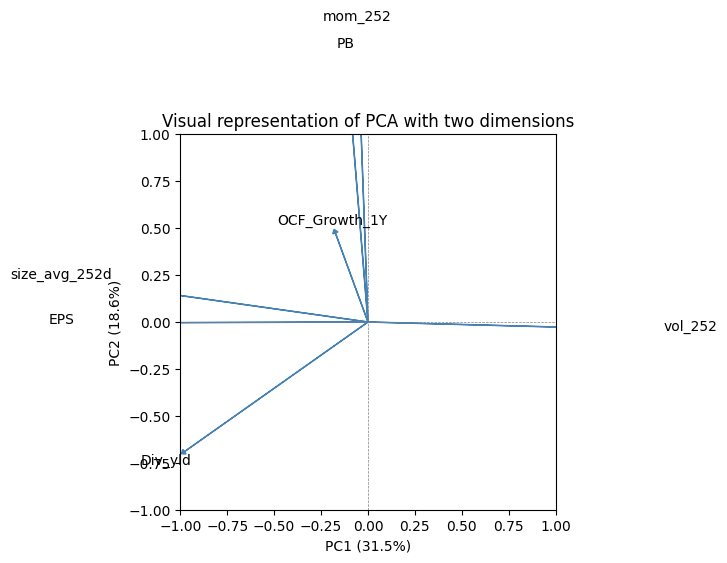

In [5]:
# PCA biplot visualization
fig, ax = plt.subplots(figsize=(8, 6))

# Scale the loadings by explained variance ratio for visualization
scale = np.sqrt(pca.explained_variance_ratio_[:2]) * 5

# Plot arrows for each feature
for i, feature in enumerate(features_short):
    ax.arrow(0, 0, 
             pca.components_[0, i] * scale[0], 
             pca.components_[1, i] * scale[1],
             head_width=0.03, head_length=0.02, fc='steelblue', ec='steelblue')
    ax.text(pca.components_[0, i] * scale[0] * 1.1, 
            pca.components_[1, i] * scale[1] * 1.1,
            feature, fontsize=10, ha='center')

# Formatting
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Visual representation of PCA with two dimensions')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

The plot shows the direction and magnitude of each feature's contribution to the first two principal components. The numbers indicated along the axes are the proportion of explained variance of each PC.

Once the rotation is known, it is possible to select a subsample of the transformed data. From the original 7 features, it is easy to pick just 4.

In [6]:
# Transform data using first 4 principal components
X_transformed = training_sample[features_short].values @ pca.components_.T[:, :4]

# Create DataFrame with transformed data
pca_df = pd.DataFrame(
    X_transformed,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
)
pca_df.head(6)

,PC1,PC2,PC3,PC4
0,-0.098630,0.751894,-0.106732,0.352415
1,-0.098418,0.752089,-0.106983,0.352410
2,-0.098323,0.752172,-0.107090,0.352408
3,-0.097859,0.752573,-0.107602,0.352397
4,-0.098096,0.752353,-0.107319,0.352402
5,-0.098096,0.752353,-0.107319,0.352402


These 4 factors can then be used as orthogonal features in any ML engine. The fact that the features are uncorrelated is undoubtedly an asset. But the price of this convenience is high: the features are no longer immediately interpretable. De-correlating the predictors adds yet another layer of "*blackbox-ing*" in the algorithm.

PCA can also be used to estimate factor models. In Equation {eq}`eq:pca`, it suffices to replace $\textbf{Z}$ with returns, $\textbf{X}$ with factor values and $\textbf{P}$ with factor loadings (see, e.g., @connor1988risk for an early reference). More recently, @lettau2018estimating and @lettau2018factors propose a thorough analysis of PCA estimation techniques. They notably argue that first moments of returns are important and should be included in the objective function, alongside the optimization on the second moments. 

We end this subsection with a technical note. Usually, PCA is performed on the covariance matrix of returns. Sometimes, it may be preferable to decompose the **correlation** matrix. The result may adjust substantially if the variables have very different variances (which is not really the case in the equity space). If the investment universe encompasses several asset classes, then a correlation-based PCA will reduce the importance of the most volatile class. In this case, it is as if all returns are scaled by their respective volatilities.

### Scree plot and explained variance

A useful diagnostic for PCA is the scree plot, which shows the proportion of variance explained by each principal component. This helps determine how many components to retain.

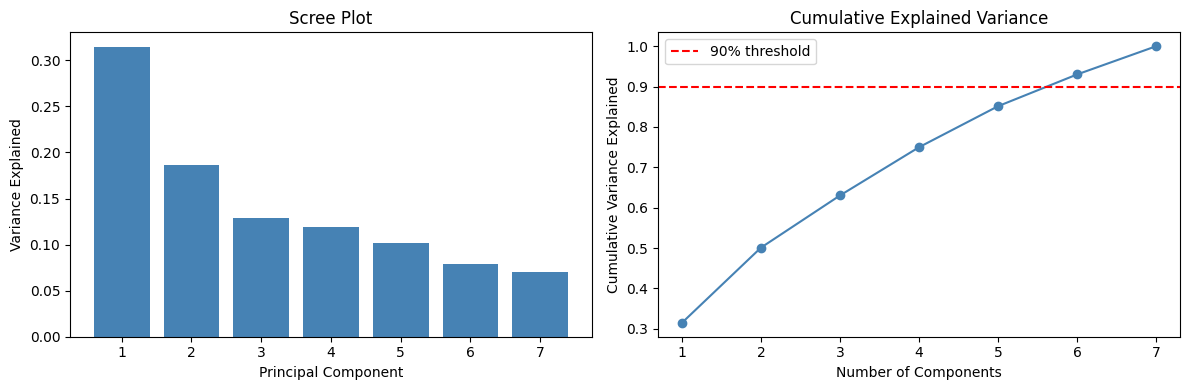


Variance explained by first 4 components: 75.0%


In [7]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Individual explained variance
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), 
            pca.explained_variance_ratio_, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))

# Cumulative explained variance
cumulative_var = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, 'o-', color='steelblue')
axes[1].axhline(y=0.9, color='red', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, len(cumulative_var) + 1))
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nVariance explained by first 4 components: {cumulative_var[3]*100:.1f}%")

(ae)=
### Autoencoders

In a PCA, the coding from $\textbf{X}$ to $\textbf{Z}$ is straightfoward, linear and works both ways:
$$\textbf{Z}=\textbf{X}\textbf{P} \quad \text{and} \quad \textbf{X}=\textbf{ZP}',$$
so that we recover $\textbf{X}$ from $\textbf{Z}$. This can be writen differently:

```{math}
:label: eq:pcascheme
\textbf{X} \quad \overset{\text{encode via }\textbf{P}}{\longrightarrow} \quad \textbf{Z} \quad \overset{\text{decode via } \textbf{P}'}{\longrightarrow} \quad \textbf{X}
```

If we take the truncated version and seek a smaller output (with only $K'$ columns), this gives:

```{math}
:label: eq:pcaschem2
\textbf{X}, \ (I\times K) \quad \overset{\text{encode via }\textbf{P}_{K'}}{\longrightarrow} \quad \tilde{\textbf{X}}, \ (I \times K') \quad \overset{\text{decode via } \textbf{P}'_{K'}}{\longrightarrow} \quad \breve{\textbf{X}},\ (I \times K),
```

where $\textbf{P}_{K'}$ is the restriction of $\textbf{P}$ to the $K'$ columns that correspond to the factors with the largest variances. The dimensions of matrices are indicated inside the brackets. In this case, the recoding cannot recover $\textbf{X}$ exactly but only an approximation, which we write $\breve{\textbf{X}}$. This approximation is coded with less information, hence this new data $\breve{\textbf{X}}$ is compressed and provides a parsimonious representation of the original sample $\textbf{X}$. 

An autoencodeur generalizes this concept to **nonlinear** coding functions. Simple linear autoencoders are linked to latent factor models (see Proposition 1 in @gu2019autoencoder for the case of single layer autoencoders.) The scheme is the following

```{math}
:label: eq:aescheme2
\textbf{X},\ (I\times K) \quad \overset{\text{encode via } N} {\longrightarrow} \quad \tilde{\textbf{X}}=N(\textbf{X}), \ (I \times K') \quad \overset{\text{decode via } N'}{\longrightarrow} \quad \breve{\textbf{X}}=N'(\tilde{\textbf{X}}), \ (I \times K),
```

where the encoding and decoding functions $N$ and $N'$ are often taken to be neural networks. The term **autoencoder** comes from the fact that the target output, which we often write $\textbf{Z}$ is the original sample $\textbf{X}$. Thus, the algorithm seeks to determine the function $N$ that minimizes the distance (to be defined) between $\textbf{X}$ and the output value $\breve{\textbf{X}}$. The encoder generates an alternative representation of $\textbf{X}$, whereas the decoder tries to recode it back to its original values. Naturally, the intermediate (coded) version $\tilde{\textbf{X}}$ is targeted to have a smaller dimension compared to $\textbf{X}$.

### Application

Autoencoders are easy to code in Keras (see Chapter {ref}`chap_nn` for more details on Keras). We use the functional API. For simplicity, we work with the small number of predictors (7). The structure of the network consists of two symmetric networks with only one intermediate layer containing 32 units. The activation function is sigmoid; this makes sense since the input has values in the unit interval.

In [8]:
import os                                                                                         
os.environ["KERAS_BACKEND"] = "jax"                                                                                                                                                                   
import keras                                                                                      
from keras import layers, Model 
import keras.ops as ops  

# Set random seed for reproducibility
import jax                                                                                        
key = jax.random.PRNGKey(42)   

# Define the autoencoder architecture
input_layer = keras.Input(shape=(7,))  # features_short has 7 columns

# Encoder
encoded = layers.Dense(32, activation='sigmoid')(input_layer)
encoded = layers.Dense(4)(encoded)  # 4 dimensions for the output layer (same as PCA example)

# Decoder
decoded = layers.Dense(32, activation='sigmoid')(encoded)
decoded = layers.Dense(7)(decoded)  # the original sample has 7 features

# Build the autoencoder model
ae_model = Model(inputs=input_layer, outputs=decoded)

# Compile with MSE loss and Adam optimizer
ae_model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

ae_model.summary()

Model: "functional"


+---------------------------------+------------------------+---------------+
| Layer (type)                    | Output Shape           |       Param # |
+---------------------------------+------------------------+---------------+
| input_layer (InputLayer)        | (None, 7)              |             0 |
+---------------------------------+------------------------+---------------+
| dense (Dense)                   | (None, 32)             |           256 |
+---------------------------------+------------------------+---------------+
| dense_1 (Dense)                 | (None, 4)              |           132 |
+---------------------------------+------------------------+---------------+
| dense_2 (Dense)                 | (None, 32)             |           160 |
+---------------------------------+------------------------+---------------+
| dense_3 (Dense)                 | (None, 7)              |           231 |
+---------------------------------+------------------------+---------------+

 Total params: 779 (3.04 KB)


 Trainable params: 779 (3.04 KB)


 Non-trainable params: 0 (0.00 B)


In the training part, we optimize the MSE and use an Adam update of the weights (see {ref}`backprop`). The evolution of loss on the training and testing samples is depicted below. The decreasing pattern shows the progress of the quality in compression.

In [9]:
# Prepare data
X_train = training_sample[features_short].values
X_test = testing_sample[features_short].values

# Train the autoencoder
history = ae_model.fit(                                                                           
      X_train, X_train,  # Input and target are the same for autoencoders                           
      epochs=15,                                                                                    
      batch_size=512,                                                                               
      validation_data=(X_test, X_test),                                                             
      verbose=1                                                                                     
  )  

447/447 -------------------- 0s 891us/step - loss: 0.0187 - mean_absolute_error: 0.0984 - val_loss: 0.0175 - val_mean_absolute_error: 0.0953


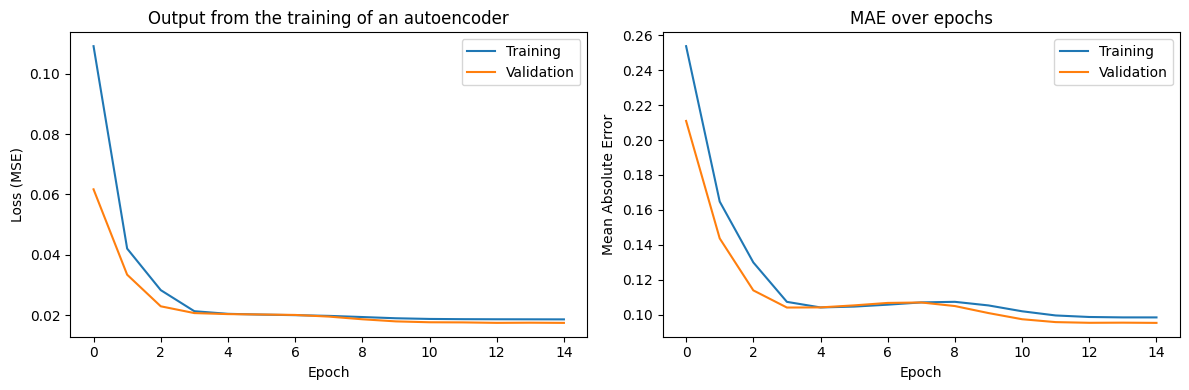

In [10]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history.history['loss'], label='Training')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Output from the training of an autoencoder')
axes[0].legend()

# MAE
axes[1].plot(history.history['mean_absolute_error'], label='Training')
axes[1].plot(history.history['val_mean_absolute_error'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].set_title('MAE over epochs')
axes[1].legend()

plt.tight_layout()
plt.show()

In order to get the details of all weights and biases, the syntax is the following.

In [11]:
# Get weights
ae_weights = ae_model.get_weights()
print(f"Number of weight arrays: {len(ae_weights)}")
for i, w in enumerate(ae_weights):
    print(f"Layer {i}: shape = {w.shape}")

Number of weight arrays: 8
Layer 0: shape = (7, 32)
Layer 1: shape = (32,)
Layer 2: shape = (32, 4)
Layer 3: shape = (4,)
Layer 4: shape = (4, 32)
Layer 5: shape = (32,)
Layer 6: shape = (32, 7)
Layer 7: shape = (7,)


Retrieving the encoder and processing the data into the compressed format is just a matter of extracting the encoder part of the model.

In [12]:
# Build encoder model (extracts the compressed representation)
encoder_model = Model(inputs=input_layer, outputs=encoded)

# Get compressed representation of training data
X_compressed = encoder_model.predict(X_train[:6])
pd.DataFrame(X_compressed, columns=['AE1', 'AE2', 'AE3', 'AE4'])

1/1 -------------------- 0s 26ms/step


,AE1,AE2,AE3,AE4
0,0.028365,0.244199,-0.137838,-0.421712
1,0.028082,0.244639,-0.137827,-0.421636
2,0.027962,0.244831,-0.137824,-0.421603
3,0.027390,0.245763,-0.137814,-0.421444
4,0.027711,0.245270,-0.137827,-0.421528
5,0.027711,0.245270,-0.137827,-0.421528


### Variational Autoencoders (VAE)

A more advanced variant is the **Variational Autoencoder** (VAE), which learns a probabilistic latent space. Instead of encoding inputs to fixed points, VAEs encode inputs to distributions, enabling smooth interpolation and generation of new samples. VAEs are particularly useful when you want to generate new synthetic data that resembles your training data.

## Visualization via t-SNE

While PCA is excellent for linear dimensionality reduction, non-linear methods like **t-SNE** (t-distributed Stochastic Neighbor Embedding) and **UMAP** (Uniform Manifold Approximation and Projection) are powerful for visualizing high-dimensional data in 2D or 3D. These methods preserve local structure better than PCA, making them ideal for discovering clusters and patterns.

Note that these methods are primarily for **visualization**, not for creating features to use in downstream models, as they don't provide a transformation that can be applied to new data out-of-the-box.

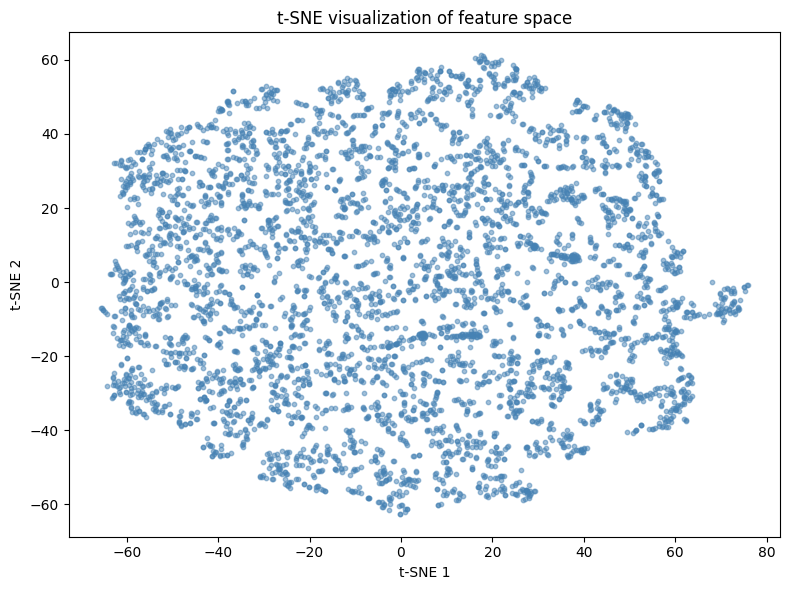

In [13]:
# Take a subsample for faster computation
np.random.seed(42)
sample_idx = np.random.choice(len(X_train), size=5000, replace=False)
X_sample = X_train[sample_idx]

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, s=10, c='steelblue')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE visualization of feature space')
plt.tight_layout()
plt.show()

## Clustering via k-means

The second family of unsupervised tools pertains to clustering. Features are grouped into homogeneous families of predictors. It is then possible to single out one among the group (or to create a synthetic average of all of them). Mechanically, the number of predictors is reduced. 

The principle is simple: among a group of variables (the reasoning would be the same for observations in the other dimension) $\textbf{x}_{\{1 \le j \le J\}}$, find the combination of $k<J$ groups that minimize

```{math}
:label: eq:kmeans
\sum_{i=1}^k\sum_{\textbf{x}\in S_i}||\textbf{x}-\textbf{m}_i||^2,
```

where $||\cdot ||$ is some norm which is usually taken to be the Euclidean $l^2$-norm. The $S_i$ are the groups and the minimization is run on the whole set of groups $\textbf{S}$. The $\textbf{m}_i$ are the group means (also called centroids or barycenters): $\textbf{m}_i=(\text{card}(S_i))^{-1}\sum_{\textbf{x}\in S_i}\textbf{x}$.

In order to ensure optimality, all possible arrangements must be tested, which is prohibitively long when $k$ and $J$ are large. Therefore, the problem is usually solved with greedy algorithms that seek (and find) solutions that are not optimal but 'good enough'. 

One heuristic way to proceed is the following:

0. Start with a (possibly random) partition of $k$ clusters.   
1. For each cluster, compute the optimal mean values $\textbf{m}_i^*$ that minimizes expression {eq}`eq:kmeans`. This is a simple quadratic program.     
2. Given the optimal centers $\textbf{m}_i^*$, reassign the points $\textbf{x}_i$ so that they are all the closest to their center.   
3. Repeat steps 1. and 2. until the points do not change cluster at step 2.   

Below, we illustrate this process with an example. From all 93 features, we build 10 clusters.

In [14]:
# K-means clustering of features (transpose to cluster columns)
np.random.seed(42)

# Get feature matrix and transpose to cluster features (columns)
X_features = training_sample[features].values.T  # Shape: (n_features, n_samples)

# Perform k-means clustering
kmeans = KMeans(n_clusters=6, random_state=42, n_init=6)
feature_clusters = kmeans.fit_predict(X_features)

# Organize clusters
clusters_df = pd.DataFrame({
    'factor': features,
    'cluster': feature_clusters
}).sort_values('cluster')

# Show one particular group (cluster 2)
print("Members of cluster 2:")
clusters_df[clusters_df['cluster'] == 2]

Members of cluster 2:


,factor,cluster
91,adv_252,2
110,size_log,2
109,size_avg_66d,2
100,log_adv_21,2
108,size_avg_252d,2
93,bb_width,2
92,adv_63,2
90,adv_180,2


We single out the fourth cluster which is composed mainly of accounting ratios. Given these 10 clusters, we can build a much smaller group of features that can then be fed to the predictive engines described in Chapters {ref}`chap_lasso` to {ref}`chap_bayes`. The representative of a cluster can be the member that is closest to the center, or simply the center itself. This pre-processing step can nonetheless cause problems in the forecasting phase. Typically, it requires that the training data be also clustered. The extension to the testing data is not straightforward (the clusters may not be the same).

In [15]:
# Show all clusters
for i in range(6):
    cluster_members = clusters_df[clusters_df['cluster'] == i]['factor'].tolist()
    print(f"\nCluster {i} ({len(cluster_members)} members):")
    print(", ".join(cluster_members[:5]), end="")
    if len(cluster_members) > 5:
        print(f", ... (+{len(cluster_members)-5} more)")
    else:
        print()


Cluster 0 (16 members):
Mom_Sharp_5M, dd, EPS_Quarterly_Surprise, ma_ratio, macd, ... (+11 more)

Cluster 1 (15 members):
Pretax_Income_Margin, PSales, PE, Gross_Margin, Net_Profit_Margin, ... (+10 more)

Cluster 2 (8 members):
adv_252, size_log, size_avg_66d, log_adv_21, size_avg_252d, ... (+3 more)

Cluster 3 (55 members):
ROIC, Normalized_ROA, OCF_Growth_1Y, OCF_to_Assets, OCF_to_NOA, ... (+50 more)

Cluster 4 (14 members):
Debt_equity, Debt_Assets, Div_yld, Capex_Intensity, Buyback_Yield, ... (+9 more)

Cluster 5 (14 members):
vol_66, vol_252, vol_22, turnover_63, turnover_252, ... (+9 more)


### Choosing the optimal number of clusters

A common question is: how many clusters should we use? Two popular methods are:

1. **Elbow method**: Plot the within-cluster sum of squares (inertia) against $k$ and look for an "elbow" where adding more clusters doesn't significantly reduce inertia.

2. **Silhouette analysis**: Measure how similar objects are to their own cluster compared to other clusters.

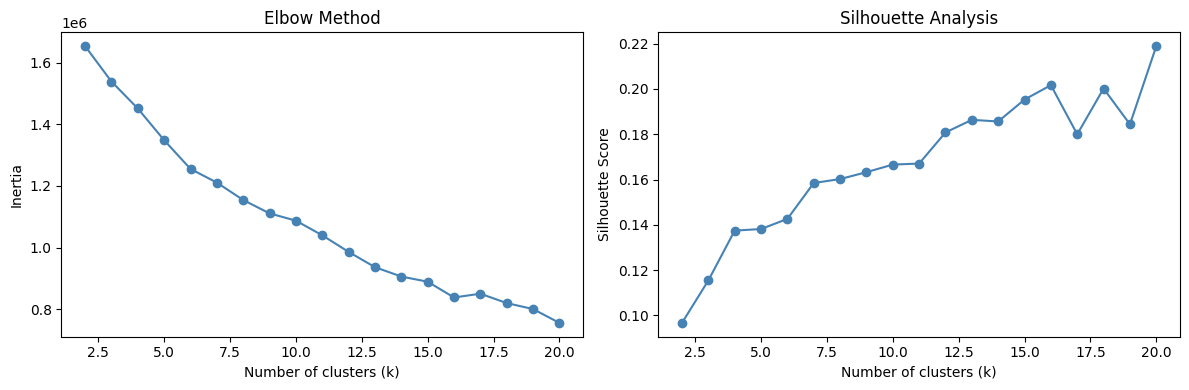

Best k by silhouette score: 20


In [16]:
# Compute metrics for different k values
k_range = range(2, 21)
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_features)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_features, kmeans.labels_))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot
axes[0].plot(k_range, inertias, 'o-', color='steelblue')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

# Silhouette plot
axes[1].plot(k_range, silhouettes, 'o-', color='steelblue')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')

plt.tight_layout()
plt.show()

print(f"Best k by silhouette score: {k_range[np.argmax(silhouettes)]}")

### Hierarchical clustering

An alternative to k-means is **hierarchical clustering**, which builds a tree of clusters. This is particularly useful when you want to visualize the relationships between features at multiple scales.

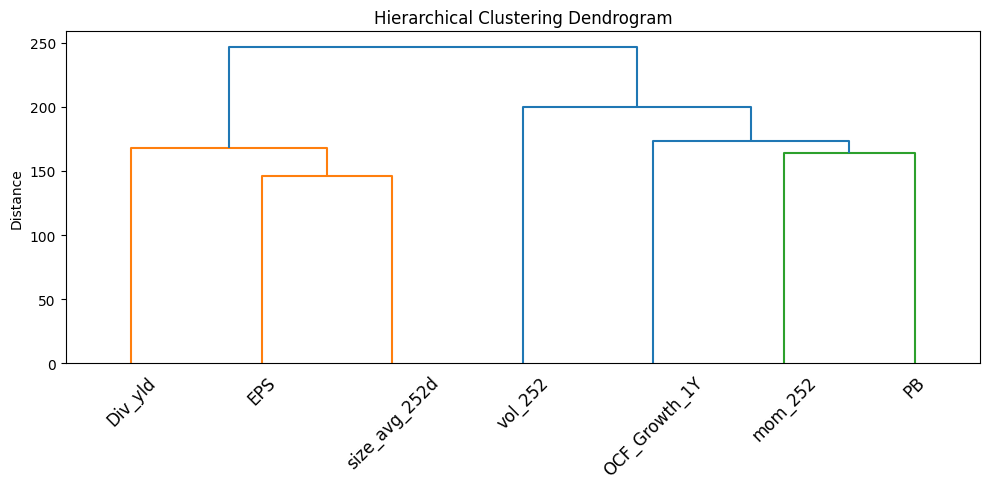

In [17]:
# Use short features for clearer visualization
X_short_T = training_sample[features_short].values.T

# Compute hierarchical clustering
linkage_matrix = linkage(X_short_T, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, labels=features_short, leaf_rotation=45)
plt.title('Hierarchical Clustering Dendrogram')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

## Nearest neighbors

To the best of our knowledge, nearest neighbors are not used in large-scale portfolio choice applications. The reason is simple: computational cost. Nonetheless, the concept of neighbors is widespread in unsupervised learning and can be used locally in complement to interpretability tools. Theoretical results on k-NN relating to bounds for error rates on classification tasks can be found in section 6.2 of @ripley2007pattern. The rationale is the following. If:   

1. the training sample is able to accurately span the distribution of $(\textbf{y}, \textbf{X})$; **and**     
2. the testing sample follows the same distribution as the training sample (or close enough);      

then the neighborhood of one instance $\textbf{x}_i$ from the testing features computed on the training sample will yield valuable information on $y_i$. 

In what follows, we thus seek to find neighbors of one particular instance $\textbf{x}_i$ (a $K$-dimensional row vector). Note that there is a major difference with the previous section: the clustering is intended at the observation level (row) and not at the predictor level (column).

Given a dataset with the same (corresponding) columns $\textbf{X}_{i,k}$, the neighbors are defined via a similarity measure (or distance)

```{math}
:label: eq:D
D(\textbf{x}_j,\textbf{x}_i)=\sum_{k=1}^Kc_k d_k(x_{j,k},x_{i,k}),
```

where the distance functions $d_k$ can operate on various data types (numerical, categorical, etc.). For numerical values, $d_k(x_{j,k},x_{i,k})=(x_{j,k}-x_{i,k})^2$ or $d_k(x_{j,k},x_{i,k})=|x_{j,k}-x_{i,k}|$. For categorical values, we refer to the exhaustive survey by @boriah2008similarity which lists 14 possible measures. Finally the $c_k$ in Equation {eq}`eq:D` allow some flexbility by weighting features. This is useful because both raw values ($x_{i,k}$ versus $x_{i,k'}$) or measure outputs ($d_k$ versus $d_{k'}$) can have different scales. 

Once the distances are computed over the whole sample, they are ranked using indices $l_1^i, \dots, l_I^i$:
$$D\left(\textbf{x}_{l_1^i},\textbf{x}_i\right) \le D\left(\textbf{x}_{l_2^i},\textbf{x}_i\right) \le \dots, \le D\left(\textbf{x}_{l_I^i},\textbf{x}_i\right)$$

The nearest neighbors are those indexed by $l_m^i$ for $m=1,\dots,k$. We leave out the case when there are problematic equalities of the type $D\left(\textbf{x}_{l_m^i},\textbf{x}_i\right)=D\left(\textbf{x}_{l_{m+1}^i},\textbf{x}_i\right)$ for the sake of simplicity and because they rarely occur in practice as long as there are sufficiently many numerical predictors.

Given these neighbors, it is now possible to build a prediction for the label side $y_i$. The rationale is straightforward: if $\textbf{x}_i$ is close to other instances $\textbf{x}_j$, then the label value $y_i$ should also be close to $y_j$ (under the assumption that the features carry some predictive information over the label $y$).

An intuitive prediction for $y_i$ is the following weighted average:
$$\hat{y}_i=\frac{\sum_{j\neq i} h(D(\textbf{x}_j,\textbf{x}_i)) y_j}{\sum_{j\neq i} h(D(\textbf{x}_j,\textbf{x}_i))},$$
where $h$ is a decreasing function. Thus, the further $\textbf{x}_j$ is from $\textbf{x}_i$, the smaller the weight in the average. A typical choice for $h$ is $h(z)=e^{-az}$ for some parameter $a>0$ that determines how penalizing the distance $D(\textbf{x}_j,\textbf{x}_i)$ is. Of course, the average can be taken in the set of $k$ nearest neighbors, in which case the $h$ is equal to zero beyond a particular distance threshold:
$$\hat{y}_i=\frac{\sum_{j \text{ neighbor}} h(D(\textbf{x}_j,\textbf{x}_i)) y_j}{\sum_{j \text{ neighbor}} h(D(\textbf{x}_j,\textbf{x}_i))}.$$

A more agnostic rule is to take $h:=1$ over the set of neighbors and in this case, all neighbors have the same weight (see the old discussion by @bailey1978note in the case of classification). For classification tasks, the procedure involves a voting rule whereby the class with the most votes wins the contest, with possible tie-breaking methods. The interested reader can have a look at the short survey in @bhatia2010survey.

For the choice of optimal $k$, several complicated techniques and criteria exist (see, e.g., @ghosh2006optimum and @hall2008choice). Heuristic values often do the job pretty well. A rule of thumb is that $k=\sqrt{I}$ ($I$ being the total number of instances) is not too far from the optimal value, unless $I$ is exceedingly large.

Below, we illustrate this concept. We pick one date (31th of December 2006) and single out one asset. We then seek to find the $k=30$ stocks that are the closest to this asset at this particular date.

In [18]:
# Dataset for k-NN exercise
knn_data = data_ml[data_ml['date'] == '2006-12-31'].copy()

# Get first stock as target
first_stock = knn_data['fsym_id'].iloc[0]
knn_target = knn_data[knn_data['fsym_id'] == first_stock][features].values
knn_sample = knn_data[knn_data['fsym_id'] != first_stock][features].values

# Fit nearest neighbors model
nn_model = NearestNeighbors(n_neighbors=30, metric='euclidean')
nn_model.fit(knn_sample)

# Find neighbors
distances, indices = nn_model.kneighbors(knn_target)

print("Indices of the k=30 nearest neighbors:")
print(indices[0])

Indices of the k=30 nearest neighbors:
[ 584  133   52  932 1153  657  982  236 1004   37  994  377  639  617
  709  589 1191 1011  813  622  873  691  914 1116  886 1047  418  219
 1010  607]


Once the neighbors and distances are known, we can compute a prediction for the return of the target stock. We use the function $h(z)=e^{-z}$ for the weighting of instances (via the distances).

In [19]:
# Get labels (returns) for neighbors
knn_sample_full = knn_data[knn_data['fsym_id'] != first_stock].reset_index(drop=True)
knn_labels = knn_sample_full.iloc[indices[0]]['R1M'].values

# Weighted prediction with h(z) = e^(-z)
weights = np.exp(-distances[0])
prediction = np.sum(knn_labels * weights) / np.sum(weights)

# True value
true_value = knn_data[knn_data['fsym_id'] == first_stock]['R1M'].values[0]

print(f"Prediction with h(z)=e^(-z): {prediction:.4f}")
print(f"True R1M value: {true_value:.4f}")

Prediction with h(z)=e^(-z): 0.0430
True R1M value: -0.0262


The prediction is neither very good, nor very bad (the sign may be correct!). However, note that this example cannot be used for predictive purposes because we use data from 2006-12-31 to predict a return at the same date. In order to avoid the forward-looking bias, the knn_sample variable should be chosen from a prior point in time. 

The above computations are fast (a handful of seconds at most), but hold for only one asset. In a $k$-NN exercise, each stock gets a customed prediction and the set of neighbors must be re-assessed each time. For $N$ assets, $N(N-1)/2$ distances must be evaluated. This is particularly costly in a backtest, especially when several parameters can be tested (the number of neighbors, $k$, or $a$ in the weighting function $h(z)=e^{-az}$). When the investment universe is small (when trading indices for instance), *k*-NN methods become computationally attractive (see for instance @chen2017feature).

### Ball Tree and KD Tree for efficient k-NN

For large datasets, scikit-learn provides optimized algorithms like Ball Tree and KD Tree that can significantly speed up nearest neighbor queries.

In [20]:
# Compare different algorithms
algorithms = ['brute', 'ball_tree', 'kd_tree']
times = {}

for algo in algorithms:
    nn = NearestNeighbors(n_neighbors=30, algorithm=algo)
    
    start = time.time()
    nn.fit(knn_sample)
    nn.kneighbors(knn_target)
    times[algo] = time.time() - start

print("Algorithm comparison (time in seconds):")
for algo, t in times.items():
    print(f"  {algo}: {t:.4f}s")

Algorithm comparison (time in seconds):
  brute: 0.0012s
  ball_tree: 0.0041s
  kd_tree: 0.0017s


## Anomaly detection with Isolation Forest

An important application of unsupervised learning in finance is **anomaly detection**. Isolation Forest is an efficient algorithm that identifies anomalies by isolating observations. Anomalies are easier to isolate and thus have shorter path lengths in the tree structure.

Number of anomalies detected: 11428 (5.0%)


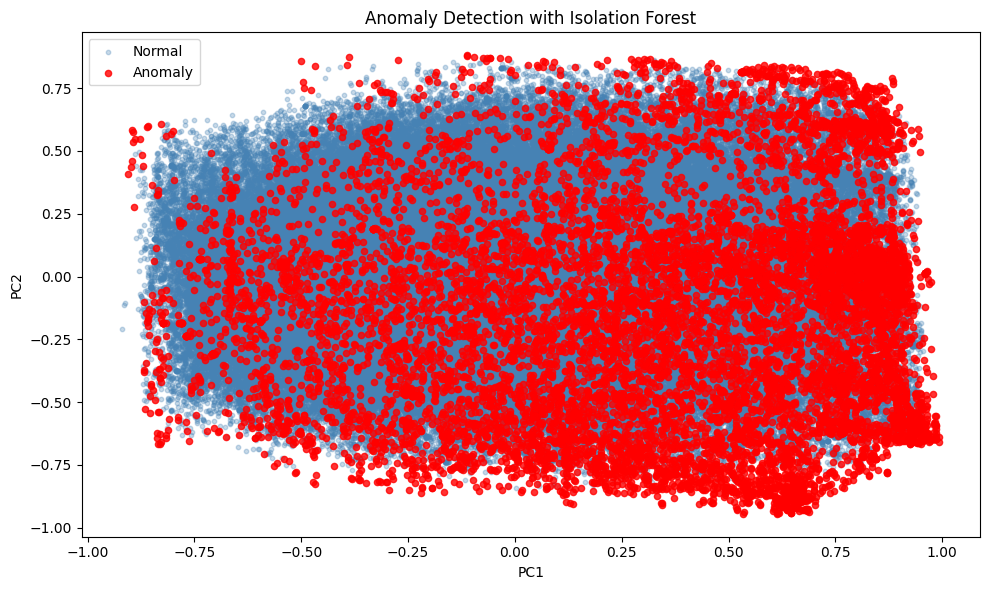

In [21]:
# Fit Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
anomaly_labels = iso_forest.fit_predict(X_train)

# Count anomalies
n_anomalies = np.sum(anomaly_labels == -1)
print(f"Number of anomalies detected: {n_anomalies} ({100*n_anomalies/len(X_train):.1f}%)")

# Visualize anomalies using PCA projection
X_pca = pca.transform(X_train)[:, :2]

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[anomaly_labels == 1, 0], X_pca[anomaly_labels == 1, 1], 
            alpha=0.3, s=10, label='Normal', c='steelblue')
plt.scatter(X_pca[anomaly_labels == -1, 0], X_pca[anomaly_labels == -1, 1], 
            alpha=0.8, s=20, label='Anomaly', c='red')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Anomaly Detection with Isolation Forest')
plt.legend()
plt.tight_layout()
plt.show()

## Coding exercise

Code the compressed version of the data (narrow training sample) via the encoder part of the autoencoder.

In [22]:
# Solution: Use the encoder model to compress data
# The encoder was already built above:
# encoder_model = Model(inputs=input_layer, outputs=encoded)

# Compress the full training data
X_compressed_full = encoder_model.predict(X_train)

# Create a DataFrame with the compressed features
compressed_df = pd.DataFrame(
    X_compressed_full,
    columns=['AE1', 'AE2', 'AE3', 'AE4']
)

print("Compressed data shape:", compressed_df.shape)
print("\nFirst few rows:")
compressed_df.head()

7143/7143 -------------------- 1s 153us/step


Compressed data shape: (228548, 4)

First few rows:


,AE1,AE2,AE3,AE4
0,0.028365,0.244199,-0.137838,-0.421712
1,0.028082,0.244639,-0.137827,-0.421636
2,0.027962,0.244831,-0.137824,-0.421603
3,0.027390,0.245763,-0.137814,-0.421444
4,0.027711,0.245270,-0.137827,-0.421528


In [23]:
# Compare compression quality: correlation between original and reconstructed
X_reconstructed = ae_model.predict(X_train)

# Compute correlation for each feature
correlations = []
for i, feat in enumerate(features_short):
    corr = np.corrcoef(X_train[:, i], X_reconstructed[:, i])[0, 1]
    correlations.append(corr)

print("Reconstruction quality (correlation original vs reconstructed):")
for feat, corr in zip(features_short, correlations):
    print(f"  {feat}: {corr:.4f}")

print(f"\nMean correlation: {np.mean(correlations):.4f}")

7143/7143 -------------------- 1s 154us/step


Reconstruction quality (correlation original vs reconstructed):
  Div_yld: 0.7822
  EPS: 0.7536
  size_avg_252d: 0.8594
  mom_252: 0.9732
  OCF_Growth_1Y: 0.9979
  PB: 0.8561
  vol_252: 0.8308

Mean correlation: 0.8648
